In [1]:
from model_ranking import (
    load_h5,
    get_random_colors,
    find_dataset_object_sizes,
)
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

INFO: P [MainThread] 2025-10-09 20:08:55,830 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
PtoO_path = Path("/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/PNAS_to_Ovules_gap/consistency/P_full/p_model_UNet1/norm_50_950")
full_summary_paths = list(PtoO_path.rglob("**/metric_summary_full.h5"))
filtered_summary_paths = list(PtoO_path.rglob("**/metric_summary_filtered.h5"))

: 

In [ ]:
for i, path in enumerate(full_summary_paths[1:]):
    aug = path.parent.parent.name
    AdaRand_scores_full = load_h5(path, "AdaRandError_consis")
    AdaRand_median_full = load_h5(path, "AdaRandError_consis_median")
    print(f"full consis scores {AdaRand_scores_full.shape}")
    print(f"full consis {aug} median {AdaRand_median_full}")

    filtered_path = filtered_summary_paths[i+1]
    assert aug in str(filtered_path), f"Mismatch in paths {path} and {filtered_path}"
    AdaRand_scores_filtered = load_h5(filtered_path, "AdaRandError_consis")
    AdaRand_median_filtered = load_h5(filtered_path, "AdaRandError_consis_median")
    print(f"filtered consis scores {AdaRand_scores_filtered.shape}")
    print(f"filtered consis {aug} median {AdaRand_median_filtered}")

full consis scores (5120, 3)
full consis gauss_a001-003 median [0. 1. 1.]
filtered consis scores (1837, 3)
filtered consis gauss_a001-003 median [0. 1. 1.]
full consis scores (5120, 3)
full consis gauss_a003-005 median [0. 1. 1.]
filtered consis scores (1837, 3)
filtered consis gauss_a003-005 median [4.5096446e-04 1.0000000e+00 1.0000000e+00]
full consis scores (5120, 3)
full consis gauss_a005-007 median [2.0556427e-04 1.0000000e+00 1.0000000e+00]
filtered consis scores (1837, 3)
filtered consis gauss_a005-007 median [0.00208769 0.99980676 0.9994906 ]
full consis scores (5120, 3)
full consis gauss_a007-01 median [0.00131511 0.9999424  0.9997864 ]
filtered consis scores (1837, 3)
filtered consis gauss_a007-01 median [0.00527196 0.9991527  0.99784017]
full consis scores (5120, 3)
full consis gauss_a01-02 median [0.00856411 0.99901783 0.99506974]
filtered consis scores (1837, 3)
filtered consis gauss_a01-02 median [0.01627689 0.99635476 0.98527986]


: 

In [9]:
print(f"Found {len(full_summary_paths)} full summary result files")
print(f"Found {len(filtered_summary_paths)} filtered summary result files")

Found 6 full summary result files
Found 6 filtered summary result files


# FlyWing to Ovules

In [18]:
path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_Ovules_gap/consistency/P_full/fw_model8/norm_50_950/none/predictions/metric_summary_full.h5"
MAP_score = load_h5(path, "MAP_05_095_median")
print(f"MAP score {MAP_score}")

MAP score 0.17777827382087708


In [19]:
path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_Ovules_gap/consistency/P_full/fw_model8/norm_50_950/gauss_a001-003/predictions/metric_summary_full.h5"
MAP_score = load_h5(path, "MAP_05_095_median")
AdaRand_score_median = load_h5(path, "AdaRandError_consis_median")
print(f"AdaRand score median {AdaRand_score_median}")
print(f"MAP score {MAP_score}")

AdaRand score median [0. 1. 1.]
MAP score 0.1755915880203247


In [24]:
FtoO_path_beta08 = Path("/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_Ovules_gap/consistency/P_full/fw_model8/norm_50_950")
FtoO_path_beta05 = Path("/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_Ovules_gap/consistency/beta_05/fw_model8/norm_50_950")
full_summary_paths_beta08 = list(FtoO_path_beta08.rglob("**/metric_summary_full.h5"))
#filtered_summary_paths = list(FtoO_path_beta08.rglob("**/metric_summary_filtered.h5"))
filtered_summary_paths_beta05 = list(FtoO_path_beta05.rglob("**/metric_summary_filtered.h5"))
print(len(full_summary_paths_beta08), len(filtered_summary_paths_beta05))

6 6


In [25]:
for i, path in enumerate(full_summary_paths_beta08[1:]):
    aug = path.parent.parent.name
    AdaRand_scores_full = load_h5(path, "AdaRandError_consis")
    AdaRand_median_full = load_h5(path, "AdaRandError_consis_median")
    print(f"full consis scores {AdaRand_scores_full.shape}")
    print(f"full consis {aug} median {AdaRand_median_full}")

    beta05_path = filtered_summary_paths_beta05[i+1]
    assert aug in str(beta05_path), f"Mismatch in paths {path} and {beta05_path}"
    AdaRand_scores_filtered = load_h5(beta05_path, "AdaRandError_consis")
    AdaRand_median_filtered = load_h5(beta05_path, "AdaRandError_consis_median")
    print(f"filtered consis scores {AdaRand_scores_filtered.shape}")
    print(f"filtered consis {aug} median {AdaRand_median_filtered}")

    # filtered_path = filtered_summary_paths[i+1]
    # assert aug in str(filtered_path), f"Mismatch in paths {path} and {filtered_path}"
    # AdaRand_scores_filtered = load_h5(filtered_path, "AdaRandError_consis")
    # AdaRand_median_filtered = load_h5(filtered_path, "AdaRandError_consis_median")
    # print(f"filtered consis scores {AdaRand_scores_filtered.shape}")
    # print(f"filtered consis {aug} median {AdaRand_median_filtered}")

full consis scores (5120, 3)
full consis gauss_a001-003 median [0. 1. 1.]
filtered consis scores (1837, 3)
filtered consis gauss_a001-003 median [2.8140313e-04 9.9998868e-01 9.9999183e-01]
full consis scores (5120, 3)
full consis gauss_a003-005 median [0. 1. 1.]
filtered consis scores (1837, 3)
filtered consis gauss_a003-005 median [0.00231834 0.99957913 0.99941975]
full consis scores (5120, 3)
full consis gauss_a005-007 median [1.7247714e-05 1.0000000e+00 9.9999988e-01]
filtered consis scores (1837, 3)
filtered consis gauss_a005-007 median [0.01023664 0.99860746 0.9973521 ]
full consis scores (5120, 3)
full consis gauss_a007-01 median [6.5065004e-05 9.9999511e-01 9.9999297e-01]
filtered consis scores (1837, 3)
filtered consis gauss_a007-01 median [0.02073066 0.99647045 0.99344915]
full consis scores (5120, 3)
full consis gauss_a01-02 median [4.7406706e-04 9.9995613e-01 9.9986136e-01]
filtered consis scores (1837, 3)
filtered consis gauss_a01-02 median [0.03841528 0.98881304 0.9623124 

In [26]:
OtoF_path = Path("/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/Ovules_to_FlyWing_gap/consistency/ov_model8_test/ov_model8/norm_50_950")
summary_paths = list(OtoF_path.rglob("**/metric_summary_full.h5"))
print(len(summary_paths))
MAP_score = load_h5(summary_paths[0], "MAP_05_095_median")
print(f"Ovules to FlyWing MAP score {MAP_score}")
for i, path in enumerate(summary_paths[1:]):
    aug = path.parent.parent.name
    AdaRand_scores = load_h5(path, "AdaRandError_consis")
    AdaRand_median = load_h5(path, "AdaRandError_consis_median")
    print(f"consis scores {AdaRand_scores.shape}")
    print(f"consis {aug} median {AdaRand_median}")

4
Ovules to FlyWing MAP score 0.608261227607727
consis scores (1440, 3)
consis gauss_a001-005 median [0.01757722 0.99365866 0.9909022 ]
consis scores (1440, 3)
consis gauss_a005-01 median [0.05604263 0.96434605 0.95700264]
consis scores (1440, 3)
consis gauss_a01-02 median [0.12448235 0.91051364 0.90737724]


# Legacy model Predictions

In [2]:
ov_raw_path = "/scratch/talks/data/Ovules/GT2x/test/N_294_final_crop_ds2_patchwise.h5"


In [4]:
gt_patched = load_h5(ov_raw_path, "label")
_, max_obj_size, _ = find_dataset_object_sizes(gt_patched)
print(max_obj_size)

5867


In [3]:
path_no_aug = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_Ovules_gap/consistency/P1/fw_model8/norm_5_95/none/predictions/N_294_final_crop_ds2_none.h5"
segs_NA = load_h5(path_no_aug, "segmentation")
preds_NA = load_h5(path_no_aug, "predictions")
MAP_score_NA = load_h5(path_no_aug, "MAP_05_095")


In [4]:
path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_Ovules_gap/consistency/P1/fw_model8/norm_5_95/gauss_a005-01/predictions/N_294_final_crop_ds2_gauss_a005-01.h5"
MAP_score = load_h5(path, "MAP_05_095")
AdaRandError_score = load_h5(path, "AdaRandError")
preds = load_h5(path, "predictions")
segs = load_h5(path, "segmentation")
patch_indexes = load_h5(path, "patch_index")
print(AdaRandError_score.shape)


(5120, 3)


In [5]:
print(np.nanmedian(1 - AdaRandError_score[:, 0]))

0.44882727


In [6]:
nan_ids = np.where(np.isnan(AdaRandError_score[:, 0]))[0]
print(len(nan_ids))

1675


In [7]:
print(nan_ids[:10])

[0 1 2 3 4 5 6 7 8 9]


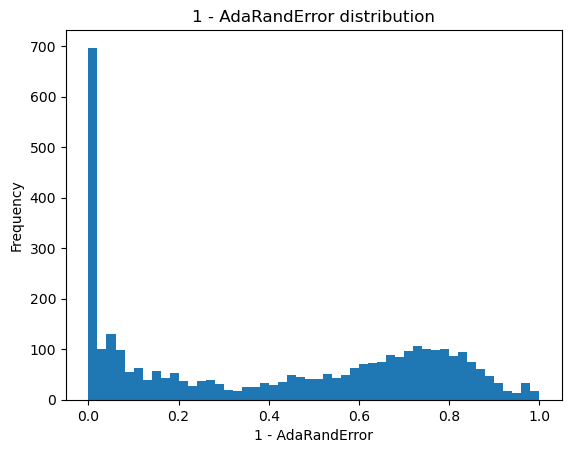

In [8]:
plt.hist(1 - AdaRandError_score[:, 0], bins=50)
plt.title("1 - AdaRandError distribution")
plt.xlabel("1 - AdaRandError")
plt.ylabel("Frequency")
plt.show()

In [9]:
ids_zero = np.where((1 -AdaRandError_score[:, 0] == 0))[0]
print(len(ids_zero))

457


In [10]:
small_consis_ids = np.where((1 -AdaRandError_score[:, 0] < 0.2) & (1 -AdaRandError_score[:, 0] > 0))[0]
print(len(small_consis_ids))

877


In [11]:
consis_ids_02_04 = np.where((1 -AdaRandError_score[:, 0] < 0.4) & (1 -AdaRandError_score[:, 0] > 0.2))[0]
print(len(consis_ids_02_04))

297


In [12]:
medium_consis_ids = np.where((1 -AdaRandError_score[:, 0] >= 0.6) & (1 -AdaRandError_score[:, 0] < 0.8))[0]
print(len(medium_consis_ids))

892


In [13]:
print(np.nanmedian((1 - AdaRandError_score[:, 0])[~ids_zero]))

0.654148


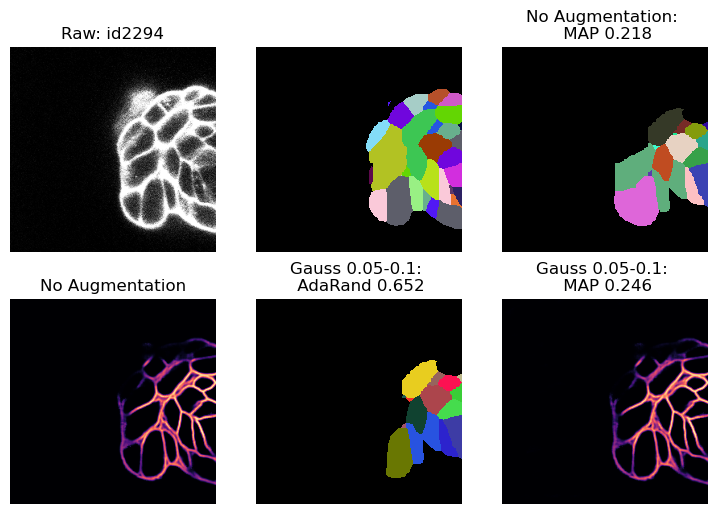

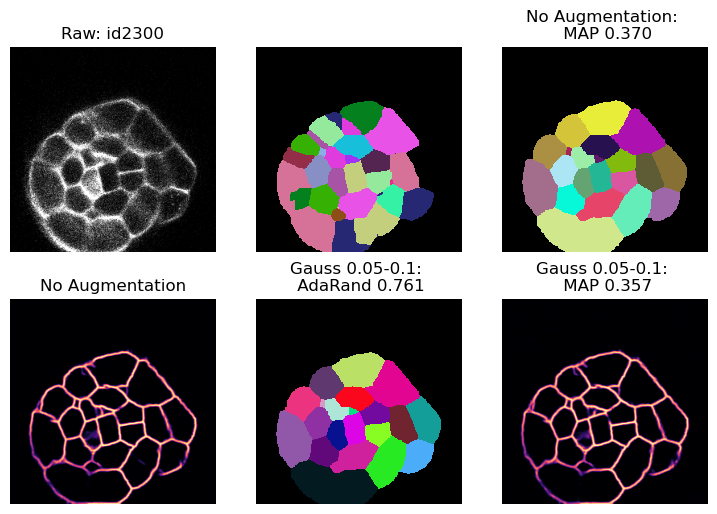

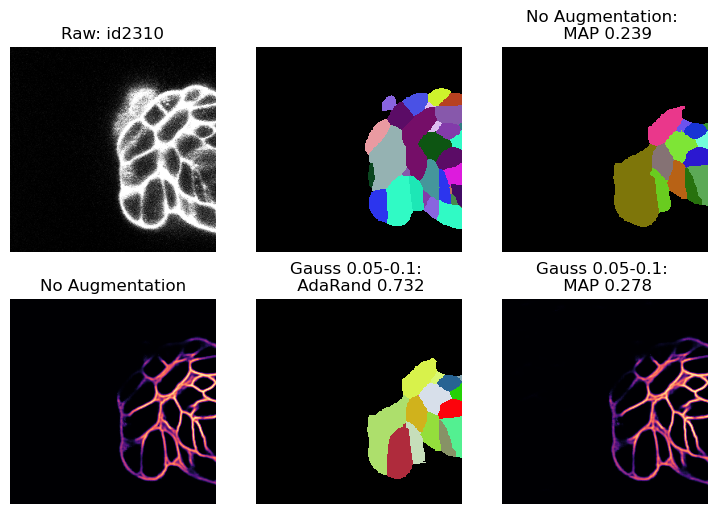

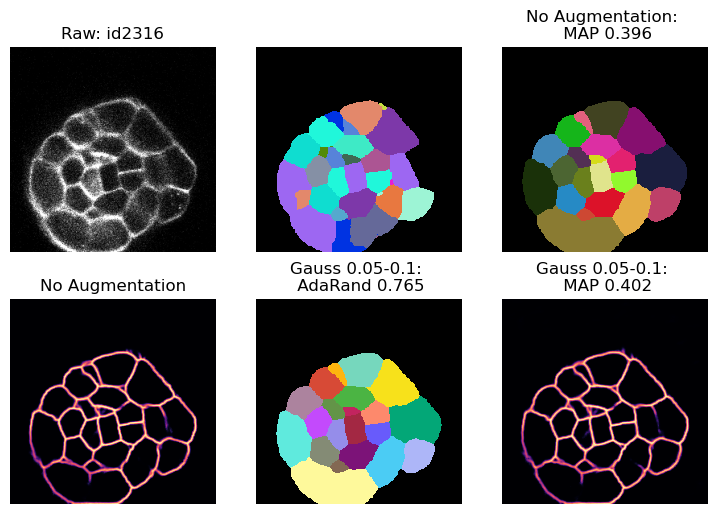

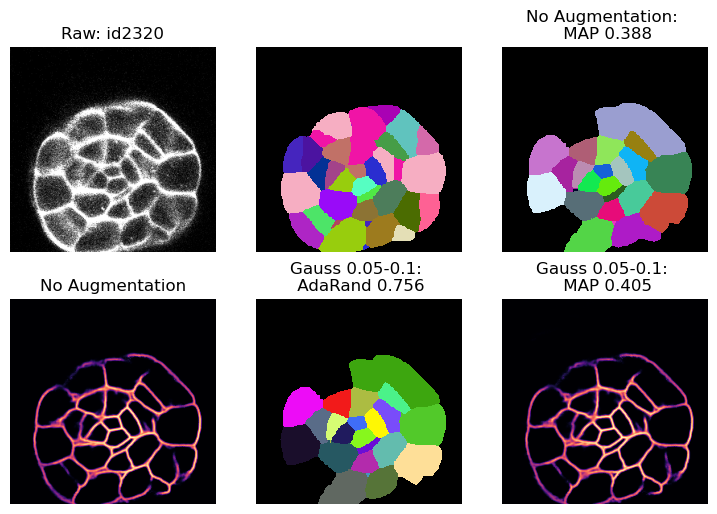

In [14]:
offset = 100
num_samples = 5
for i in medium_consis_ids[offset :offset + num_samples]:
    raw = load_h5(ov_raw_path, "raw", select_index=[i])
    gt = load_h5(ov_raw_path, "label", select_index=[i])
    _, axs = plt.subplots(2, 3, figsize=(9, 6))
    axs = axs.ravel()
    axs[0].imshow(raw.squeeze(), cmap="gray")
    axs[0].set_title(f"Raw: id{i}")
    axs[0].axis("off")
    axs[1].imshow(gt.squeeze(), cmap=get_random_colors(gt), interpolation='nearest')
    axs[1].axis("off")
    axs[2].imshow(segs_NA[i].squeeze(), cmap=get_random_colors(segs[i]), interpolation='nearest')
    axs[2].set_title("No Augmentation: \n MAP {:.3f}".format(MAP_score_NA[i]))
    axs[2].axis("off")
    axs[3].imshow(preds_NA[i].squeeze(), cmap="magma")
    axs[3].set_title("No Augmentation")
    axs[3].axis("off")
    axs[4].imshow(segs[i].squeeze(), cmap=get_random_colors(segs[i]), interpolation='nearest')
    axs[4].set_title("Gauss 0.05-0.1: \n AdaRand {:.3f}".format(1 - AdaRandError_score[i, 0]))
    axs[4].axis("off")
    axs[5].imshow(preds[i].squeeze(), cmap="magma")
    axs[5].set_title("Gauss 0.05-0.1: \n MAP {:.3f}".format(MAP_score[i]))
    axs[5].axis("off")
    plt.show()

In [15]:
path_no_aug_new = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_Ovules_gap/consistency/legacy_model/fw_model8/norm_50_950/none/predictions/N_294_final_crop_ds2_predictions.h5"
segs_NA_new = load_h5(path_no_aug_new, "segmentation")
preds_NA_new = load_h5(path_no_aug_new, "predictions")
MAP_score_NA_new = load_h5(path_no_aug_new, "MAP_05_095")

In [16]:
path_new = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_Ovules_gap/consistency/legacy_model/fw_model8/norm_50_950/gauss_a005-01/predictions/N_294_final_crop_ds2_predictions.h5"
MAP_score_new = load_h5(path_new, "MAP_05_095")
AdaRandError_score_new = load_h5(path_new, "AdaRandError_consis")
preds_new = load_h5(path_new, "predictions")
segs_new = load_h5(path_new, "segmentation")
patch_indexes_new = load_h5(path_new, "patch_index")
print(AdaRandError_score_new.shape)

(5120, 3)


In [17]:
nan_ids = np.where(np.isnan(AdaRandError_score_new[:, 0]))[0]
print(len(nan_ids))

0


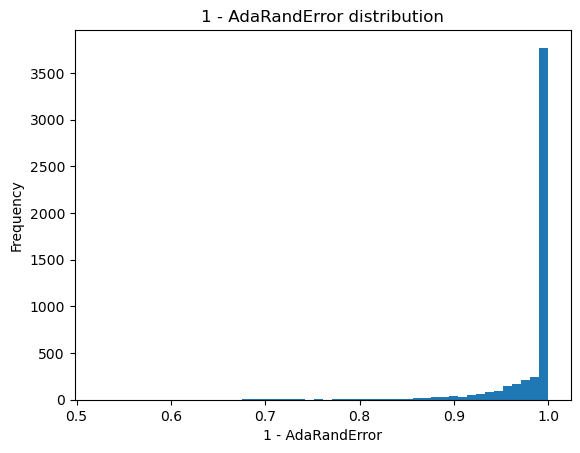

In [18]:
plt.hist(1 - AdaRandError_score_new[:, 0], bins=50)
plt.title("1 - AdaRandError distribution")
plt.xlabel("1 - AdaRandError")
plt.ylabel("Frequency")
plt.show()

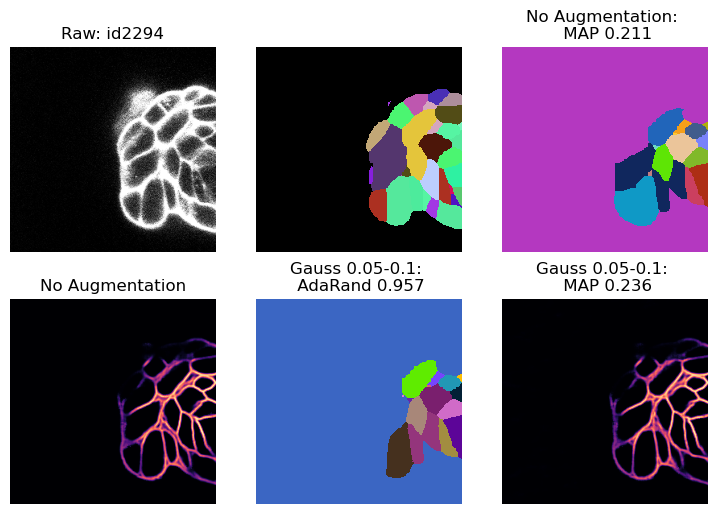

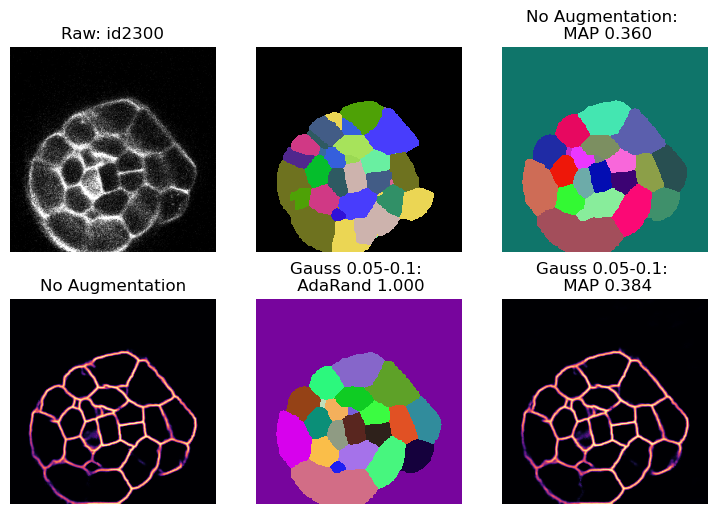

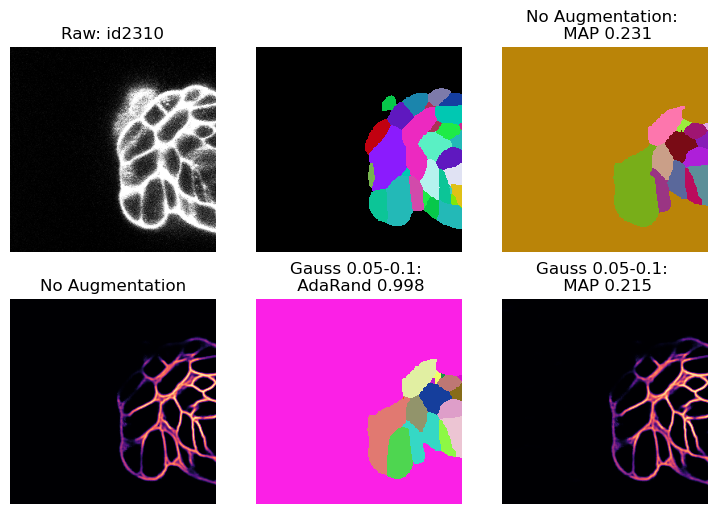

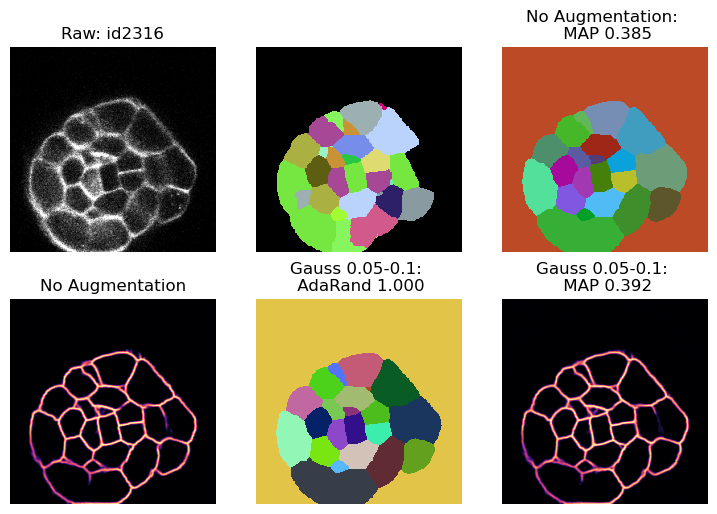

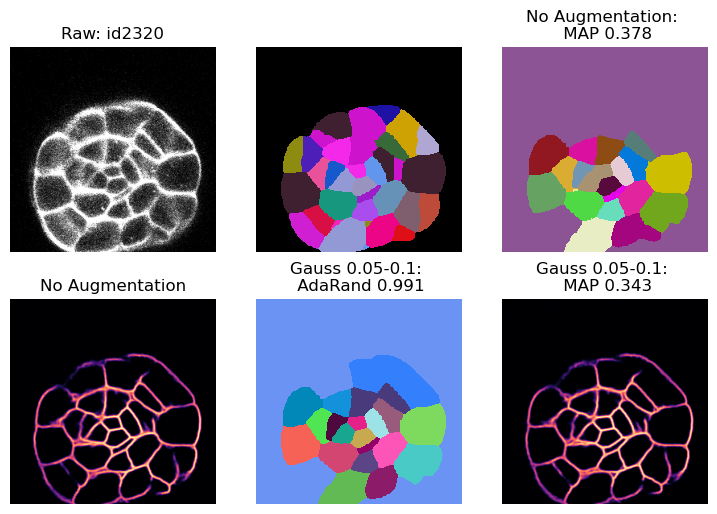

In [19]:
offset = 100
num_samples = 5
for i in medium_consis_ids[offset :offset + num_samples]:
    raw = load_h5(ov_raw_path, "raw", select_index=[i])
    gt = load_h5(ov_raw_path, "label", select_index=[i])
    _, axs = plt.subplots(2, 3, figsize=(9, 6))
    axs = axs.ravel()
    axs[0].imshow(raw.squeeze(), cmap="gray")
    axs[0].set_title(f"Raw: id{i}")
    axs[0].axis("off")
    axs[1].imshow(gt.squeeze(), cmap=get_random_colors(gt), interpolation='nearest')
    axs[1].axis("off")
    axs[2].imshow(segs_NA_new[i].squeeze(), cmap=get_random_colors(segs_new[i]), interpolation='nearest')
    axs[2].set_title("No Augmentation: \n MAP {:.3f}".format(MAP_score_NA_new[i]))
    axs[2].axis("off")
    axs[3].imshow(preds_NA_new[i].squeeze(), cmap="magma")
    axs[3].set_title("No Augmentation")
    axs[3].axis("off")
    axs[4].imshow(segs_new[i].squeeze(), cmap=get_random_colors(segs_new[i]), interpolation='nearest')
    axs[4].set_title("Gauss 0.05-0.1: \n AdaRand {:.3f}".format(1 - AdaRandError_score_new[i, 0]))
    axs[4].axis("off")
    axs[5].imshow(preds_new[i].squeeze(), cmap="magma")
    axs[5].set_title("Gauss 0.05-0.1: \n MAP {:.3f}".format(MAP_score_new[i]))
    axs[5].axis("off")
    plt.show()

# Compare AdaRandError Consis

In [20]:
from typing import Literal, Optional, Dict, Tuple, Any
import numpy as np
from numpy.typing import NDArray
from skimage.morphology import erosion, dilation #pyright: ignore
from skimage.metrics import adapted_rand_error #pyright: ignore

def get_mask(pred_none: NDArray[Any], pred_aug: NDArray[Any], threshold: float = 0.5) -> NDArray[Any]:
    masks = np.zeros((2, *pred_none.shape))
    masks[0] = pred_none > threshold
    masks[1] = pred_aug > threshold
    # Combine masks across augmentations (Union)
    combined_mask = np.logical_or.reduce(masks, axis=0)
    return combined_mask


def set_background_to_value(segmentation_image: NDArray[Any], value: int = 0) -> NDArray[Any]:    
    """
    Set the largest segment (usually this is the background but not always) to a certain value.

    Args:
        segmentation_image (np.ndarray): segmentation image to relabel
        value (int): value to set the background to, default is 0

    Returns:
        new_segmentation_image (np.ndarray): segmentation image with background set to value
    """
    segmentation_image = segmentation_image.copy()
    segmentation_image += 1
    idx, counts = np.unique(segmentation_image, return_counts=True)
    bg_idx = idx[np.argmax(counts)]
    return np.where(segmentation_image == bg_idx, value, segmentation_image)


def get_border_mask(img: NDArray[Any], num_dilations: int = 1, num_erosions: int = 1) -> NDArray[Any]:
    dilated = img.copy()
    eroded = img.copy()
    for _ in range(num_dilations):
        dilated = dilation(dilated) #pyright: ignore
    for _ in range(num_erosions):
        eroded = erosion(eroded) #pyright: ignore
    # return np.logical_and(dilated != eroded, img == 0)
    return (dilated - eroded) > 0 #pyright: ignore


def assign_unique_ids_to_value(data: NDArray[Any], value: int = 0) -> NDArray[Any]:
    data = data.copy()
    max_val = np.max(data)
    max_id_assigned = max_val + np.sum(data == value) + 1
    # check for overflow error
    if np.iinfo(data.dtype).max < max_id_assigned:
        for dtype in [np.uint16, np.uint32, np.uint64]:
            if np.iinfo(dtype).max >= max_id_assigned:
                # incease dtype size by one
                data = data.astype(dtype)
                break
        assert np.iinfo(data.dtype).max >= max_id_assigned, "Overflow error"
    data[data == value] = np.arange(max_val + 1, max_id_assigned)
    return data


def adapted_rand_consis_metric( #pyright: ignore
    aug_pred: NDArray[Any], no_aug_pred: NDArray[Any], mask: NDArray[Any], border_params: Dict[str, int] = {"num_dilations": 1, "num_erosions": 1}
):
    if aug_pred.ndim == 2:
        if np.sum(mask) == 0:
            metric_result = np.array([np.nan])
            consis_mask = mask
        else:
            if np.sum(no_aug_pred) != 0:
                border_mask = get_border_mask(no_aug_pred, **border_params)
                consis_mask = np.logical_and(mask, ~border_mask)
            else:
                consis_mask = mask
            if np.sum(consis_mask) == 0:
                metric_result = np.array([np.nan])
            else:
                metric_result = np.array( #pyright: ignore
                    adapted_rand_error( #pyright: ignore
                        assign_unique_ids_to_value(no_aug_pred[consis_mask]),
                        assign_unique_ids_to_value(aug_pred[consis_mask]),
                        ignore_labels=None,
                    )[0]
                )
    else:
        metric_result = np.zeros(len(aug_pred))
        consis_masks = np.zeros_like(mask)
        for i in range(len(aug_pred)):
            # if mask empty set to None
            if np.sum(mask[i]) == 0:
                metric_result[i] = np.array([np.nan])
                consis_masks[i] = mask[i]
            else:
                if np.sum(no_aug_pred[i]) != 0:
                    border_mask = get_border_mask(no_aug_pred[i])
                    consis_mask = np.logical_and(mask[i], ~border_mask)
                else:
                    consis_mask = mask[i]
                if np.sum(consis_mask) == 0:
                    metric_result[i] = np.array([np.nan])
                else:
                    metric_result[i] = adapted_rand_error(
                        assign_unique_ids_to_value(no_aug_pred[i][consis_mask]),
                        assign_unique_ids_to_value(aug_pred[i][consis_mask]),
                        ignore_labels=None,
                    )[0]
                consis_masks[i] = consis_mask
        consis_mask = consis_masks
    return metric_result, consis_mask #pyright: ignore


def calc_seg_consistency_metric(
    aug_pred: NDArray[Any],
    no_aug_pred: NDArray[Any],
    metric: Literal[
        "AdaRand-Error",
    ],
    ignore_mask: Optional[NDArray[Any]] = None,
    threshold: float = 0.5,
    border_params: Optional[Dict[str, int]] = {"num_dilations": 1, "num_erosions": 1},
) -> Tuple[NDArray[Any], NDArray[Any]]:
    """Calculate consistency metric between single aug pred array and non augmented pred array.
    The metric is calculated for pixels above threshold and set to None for non selected pixels.
    The output has the same shape as the input arrays with singleton dimensions removed.

    Args:
        aug_pred (np.ndarray): test time augmented prediction array
        no_aug_pred (np.ndarray): non augmented prediction array
        metric (Literal["Diff";, "EI", "Entropy"]): consistency metric type
        threshold (float, optional): prediction threshold to calculate consistency on. Defaults to 0.5.

    Returns:
        np.ndarray: consistency metric array with same shape as input arrays with singleton
        dimensions removed.
    """
    # Identify selected pixels (Union of aug and non
    # aug pixel predictions above threshold)
    mask = get_mask(no_aug_pred, aug_pred, threshold)
    if ignore_mask is not None:
        mask = np.logical_and(mask, ~ignore_mask.astype(bool))

    
    elif metric == "AdaRand-Error":
        metric_result, mask = adapted_rand_consis_metric( #pyright: ignore
            aug_pred, no_aug_pred, mask, border_params #pyright: ignore
        )
        return metric_result, mask#pyright: ignore

    # Remove singleton dimensions
    metric_result = np.squeeze(metric_result)#pyright: ignore
    mask = np.squeeze(mask)
    # invert mask to get non selected pixels
    mask_inverted = np.logical_not(mask)
    # set non selected pixels to None
    metric_result[mask_inverted] = None
    return metric_result, mask#pyright: ignore

In [21]:
segs[2294].shape

(1, 1, 256, 256)

In [22]:
gt = load_h5(ov_raw_path, "label", select_index=[2294])
print(np.unique(gt))

[   0  316  718 1002 1306 1395 1452 1578 1738 2015 2027 2102 2209 2343
 2564 2681 2799 2962 3163 3360 3370 3782 4121 4221 4268 4596 4923 4952
 5071 5127 5330 5680 5693 6285 6438]


In [23]:
id = 2981
np.unique(segs[id])

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26], dtype=uint16)

In [ ]:
from model_ranking import (
    adaRandError_eval,
)
from plantseg.functionals.dataprocessing import (  # pyright: ignore[reportMissingTypeStubs]
    set_biggest_instance_to_zero,  # pyright: ignore[reportUnknownVariableType]
)
from pytorch3dunet.unet3d.utils import (
    set_large_instances_to_zero,  # pyright: ignore[reportUnknownVariableType]
)

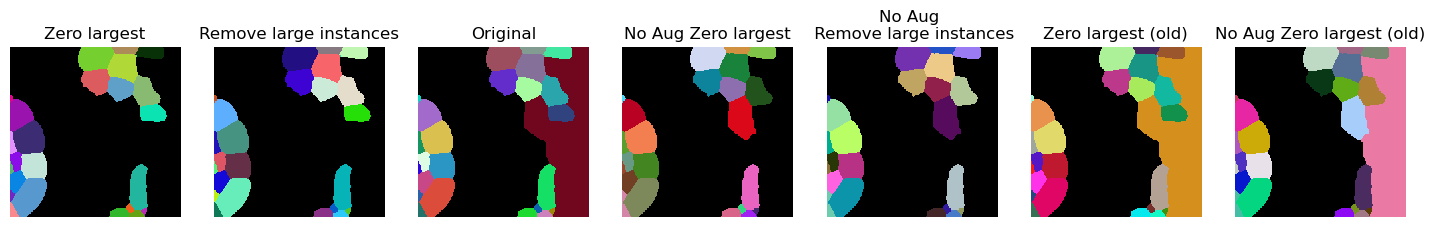

In [25]:
id = 2981
pred_NA_zero_largest = set_biggest_instance_to_zero(  # pyright: ignore[reportUnknownVariableType]
    segs_NA[id], instance_could_be_zero=False
)
pred_NA_zero_large_instances = set_large_instances_to_zero(
    segs_NA[id],
    threshold_multiplier=4
)
pred_zero_largest = set_biggest_instance_to_zero(  # pyright: ignore[reportUnknownVariableType]
    segs[id], instance_could_be_zero=False
)
pred_zero_large_instances = set_large_instances_to_zero(
    segs[id],
    threshold_multiplier=6
)

pred_zero_big_old = set_background_to_value(segs[id], value=0)
preds_NA_big_old = set_background_to_value(segs_NA[id], value=0)


_, axs = plt.subplots(1, 7, figsize=(18, 3))
axs[0].imshow(pred_zero_largest.squeeze(), cmap=get_random_colors(pred_zero_largest), interpolation='nearest')
axs[0].set_title("Zero largest")
axs[0].axis("off")
axs[1].imshow(pred_zero_large_instances.squeeze(), cmap=get_random_colors(pred_zero_large_instances), interpolation='nearest')
axs[1].set_title("Remove large instances")
axs[1].axis("off")
axs[2].imshow(segs[id].squeeze(), cmap=get_random_colors(segs[id]), interpolation='nearest')
axs[2].set_title("Original")
axs[2].axis("off")
axs[3].imshow(pred_NA_zero_largest.squeeze(), cmap=get_random_colors(pred_NA_zero_largest), interpolation='nearest')
axs[3].set_title("No Aug Zero largest")
axs[3].axis("off")
axs[4].imshow(pred_NA_zero_large_instances.squeeze(), cmap=get_random_colors(pred_NA_zero_large_instances), interpolation='nearest')
axs[4].set_title("No Aug \n Remove large instances")
axs[4].axis("off")
axs[5].imshow(pred_zero_big_old.squeeze(), cmap=get_random_colors(pred_zero_big_old), interpolation='nearest')
axs[5].set_title("Zero largest (old)")
axs[5].axis("off")
axs[6].imshow(preds_NA_big_old.squeeze(), cmap=get_random_colors(preds_NA_big_old), interpolation='nearest')
axs[6].set_title("No Aug Zero largest (old)")
axs[6].axis("off")
plt.show()

In [26]:


consis_score, consis_mask = calc_seg_consistency_metric(
    pred_zero_big_old.squeeze(),
    preds_NA_big_old.squeeze(),
    metric="AdaRand-Error",
    threshold=0.5,
)
print(1 - consis_score, consis_mask.shape)

0.8430651576304918 (256, 256)


In [27]:
id = 2981

consis_score, consis_mask = calc_seg_consistency_metric(
    segs[id].squeeze(),
    segs_NA[id].squeeze(),
    metric="AdaRand-Error",
    threshold=0.5,
)
print(1 - consis_score, consis_mask.shape)

0.8430651576304918 (256, 256)


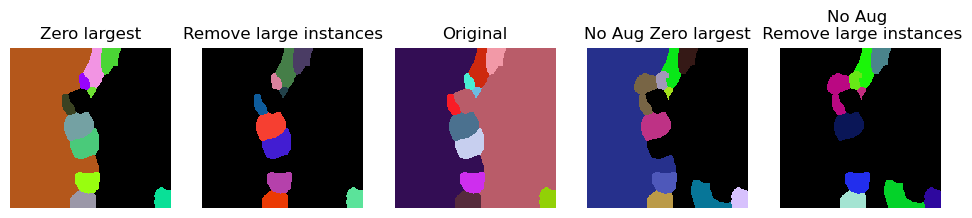

In [28]:
id = 3421
pred_NA_zero_largest = set_biggest_instance_to_zero(  # pyright: ignore[reportUnknownVariableType]
    segs_NA_new[id], instance_could_be_zero=True
)
pred_NA_zero_large_instances = set_large_instances_to_zero(
    segs_NA_new[id],
    threshold_multiplier=4
)
pred_zero_largest = set_biggest_instance_to_zero(  # pyright: ignore[reportUnknownVariableType]
    segs_new[id], instance_could_be_zero=True
)
pred_zero_large_instances = set_large_instances_to_zero(
    segs_new[id],
    threshold_multiplier=6
)
_, axs = plt.subplots(1, 5, figsize=(12, 3))
axs[0].imshow(pred_zero_largest.squeeze(), cmap=get_random_colors(pred_zero_largest), interpolation='nearest')
axs[0].set_title("Zero largest")
axs[0].axis("off")
axs[1].imshow(pred_zero_large_instances.squeeze(), cmap=get_random_colors(pred_zero_large_instances), interpolation='nearest')
axs[1].set_title("Remove large instances")
axs[1].axis("off")
axs[2].imshow(segs_new[id].squeeze(), cmap=get_random_colors(segs_new[id]), interpolation='nearest')
axs[2].set_title("Original")
axs[2].axis("off")
axs[3].imshow(pred_NA_zero_largest.squeeze(), cmap=get_random_colors(pred_NA_zero_largest), interpolation='nearest')
axs[3].set_title("No Aug Zero largest")
axs[3].axis("off")
axs[4].imshow(pred_NA_zero_large_instances.squeeze(), cmap=get_random_colors(pred_NA_zero_large_instances), interpolation='nearest')
axs[4].set_title("No Aug \n Remove large instances")
axs[4].axis("off")
plt.show()

In [29]:
score, mask = adaRandError_eval(
    pred_zero_large_instances.squeeze(),
    pred_NA_zero_large_instances.squeeze(),
    incomplete_gt=False,
)
print(1 - score[0,0])
print(mask.shape)

0.706745982170105
(1, 256, 256)


In [30]:
score, mask = adaRandError_eval(
    pred_zero_largest.squeeze(),
    pred_NA_zero_largest.squeeze(),
    incomplete_gt=False,
)
print(1 - score[0,0])
print(mask.shape)

0.9649955071508884
(1, 256, 256)


In [31]:
consis_score, consis_mask = calc_seg_consistency_metric(
    pred_zero_largest.squeeze(),
    pred_NA_zero_largest.squeeze(),
    metric="AdaRand-Error",
    threshold=0.5,
)
print(1 - consis_score, consis_mask.shape)

0.9649955078524122 (256, 256)


In [32]:
np.unique(segs[1511])

array([0], dtype=uint16)

In [33]:
id = 1511
score, mask = adaRandError_eval(
    segs_new[id].squeeze(),
    segs_NA_new[id].squeeze(),
    incomplete_gt=False,
)
print(1 - score[0,0])
print(mask.shape)

1.0
(1, 256, 256)


In [34]:
consis_score, consis_mask = calc_seg_consistency_metric(
    segs[id].squeeze(),
    segs_NA[id].squeeze(),
    metric="AdaRand-Error",
    threshold=0.5,
)
print(1 - consis_score, consis_mask.shape)

[nan] (256, 256)


In [52]:
gt_patchwise = load_h5(ov_raw_path, "label")
print(gt_patchwise.shape)

(5120, 256, 256)


In [35]:
ignore_mask = load_h5("/scratch/talks/data/Ovules/GT2x/test/N_294_final_crop_ds2.h5", "ignore_mask")
print(ignore_mask.shape)

(320, 960, 1000)


In [50]:
from model_ranking import (
    StandardEvalDataset,
    loader_classes,
    EvalDatasetConfig

)

eval_dataset_config = {
    "name": "StandardEvalDataset",
    "aug_name": "gauss_a005-01",
    "pred_path": ["/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_Ovules_gap/consistency/legacy_model/fw_model8/norm_50_950/gauss_a005-01/predictions"],
    "gt_path": ["/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_Ovules_gap/consistency/legacy_model/fw_model8/norm_50_950/none/predictions"],
    "pred_key": "segmentation",
    "gt_key": "segmentation",
    "patch_key": "patch_index",
    "roi": None,
    "ignore_index": None,
    "ignore_path": "/scratch/talks/data/Ovules/GT2x/test/N_294_final_crop_ds2.h5",
    "ignore_key": "ignore_mask",
    "convert_to_binary_label": False,
    "convert_to_boundary_label": False,
    "gt_zero_largest_instance": False,
    "gt_zero_large_instances": True,
    "min_object_size": 1,
    "zero_large_instances": True,
    "zero_largest_instance": True
}

consis_cfg = EvalDatasetConfig.model_validate(eval_dataset_config)

dataset_class = loader_classes(consis_cfg.name)
consis_datasets = dataset_class.create_datasets(consis_cfg)

# consis_dataset = StandardEvalDataset(
#     "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_Ovules_gap/consistency/legacy_model/fw_model8/norm_50_950/gauss_a005-01/predictions/N_294_final_crop_ds2_predictions.h5",
#     "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_Ovules_gap/consistency/legacy_model/fw_model8/norm_50_950/none/predictions/N_294_final_crop_ds2_predictions.h5",
#     pred_key="segmentation",
#     gt_key="segmentation",
#     roi=None,
#     ignore_index=None,
#     ignore_path="/scratch/talks/data/Ovules/GT2x/test/N_294_final_crop_ds2.h5",
#     ignore_key="ignore_mask",
#     convert_to_boundary_label=False,
#     convert_to_binary_label=False,
#     min_object_size=1,
#     gt_zero_largest_instance=False,
#     zero_large_instances=False,
#     zero_largest_instance=True,
# )
consis_dataset = consis_datasets[0]
print(len(consis_dataset))

5120


(1, 1, 256, 256) (1, 1, 256, 256)


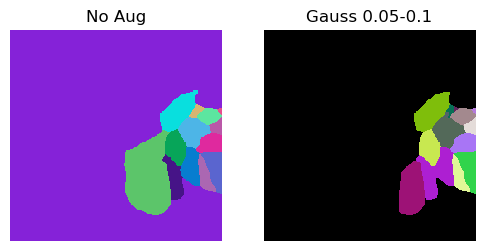

In [51]:
pred, no_aug_pred = consis_dataset[2310]
print(pred.shape, no_aug_pred.shape)
_, axs = plt.subplots(1, 2, figsize=(6, 3))
axs[0].imshow(no_aug_pred.squeeze(), cmap=get_random_colors(no_aug_pred), interpolation='nearest')
axs[0].set_title("No Aug")
axs[0].axis("off")
axs[1].imshow(pred.squeeze(), cmap=get_random_colors(pred), interpolation='nearest')
axs[1].set_title("Gauss 0.05-0.1")
axs[1].axis("off")
plt.show()


In [39]:
score, mask = adaRandError_eval(
    pred,
    no_aug_pred,
    incomplete_gt=False,
)
print(1 - score[0,0])
print(mask.shape)

0.7494924068450928
(1, 1, 256, 256)


  0%|          | 0/1 [00:00<?, ?it/s]

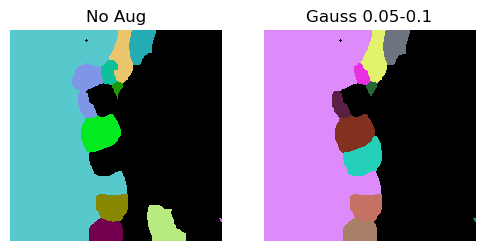

100%|██████████| 1/1 [00:00<00:00, 12.60it/s]

[[0.03478117 0.9962693  0.93604535]]


In [40]:
from tqdm import trange, tqdm
from model_ranking import get_roi_slice

consis_scores = np.zeros((segs.shape[0], 3), dtype=np.float32)
#for i in trange(segs.shape[0]):
for i in tqdm([3421]):
    patch_roi = get_roi_slice(patch_indexes_new[i])
    ignore_mask_patch = ignore_mask[patch_roi]
    p_seg =  set_biggest_instance_to_zero(  # pyright: ignore[reportUnknownVariableType]
        segs_new[i], instance_could_be_zero=True
    ).squeeze()
    unp_seg = set_biggest_instance_to_zero(  # pyright: ignore[reportUnknownVariableType]
        segs_NA_new[i], instance_could_be_zero=True
    ).squeeze()
    
    # Apply ignore mask - set both segmentations to 0 where ignore_mask is True
    p_seg[ignore_mask_patch.squeeze() == 1] = 0
    unp_seg[ignore_mask_patch.squeeze() == 1] = 0

    _, axs = plt.subplots(1, 2, figsize=(6, 3))
    axs[0].imshow(unp_seg, cmap=get_random_colors(unp_seg), interpolation='nearest')
    axs[0].set_title("No Aug")
    axs[0].axis("off")
    axs[1].imshow(p_seg, cmap=get_random_colors(p_seg), interpolation='nearest')
    axs[1].set_title("Gauss 0.05-0.1")
    axs[1].axis("off")
    plt.show()

    score, _ = adaRandError_eval(
        p_seg,
        unp_seg,
        incomplete_gt=False,
    )
    print(score)
    consis_scores[i] = score

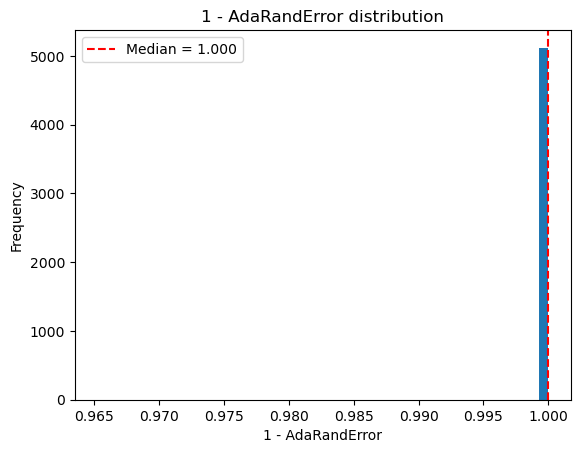

In [41]:
plt.hist(1 - consis_scores[:, 0], bins=50)
plt.axvline(x=(1-np.nanmedian(consis_scores[:, 0])), color='r', linestyle='--', label='Median = {:.3f}'.format(1-np.nanmedian(consis_scores[:, 0])))
plt.title("1 - AdaRandError distribution")
plt.xlabel("1 - AdaRandError")
plt.ylabel("Frequency")
plt.legend()
plt.show()

  0%|          | 0/1 [00:00<?, ?it/s]

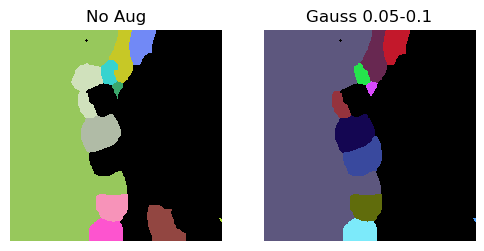

100%|██████████| 1/1 [00:00<00:00, 10.17it/s]

[[0.03478117 0.9962693  0.93604535]]


In [43]:
from tqdm import tqdm, trange
consis_scores2 = np.zeros((segs.shape[0], 3), dtype=np.float32)
# for i in trange(len(consis_dataset)):
for i in tqdm([3421]):
    pred, no_aug_pred = consis_dataset[i]
    _, axs = plt.subplots(1, 2, figsize=(6, 3))
    axs[0].imshow(no_aug_pred.squeeze(), cmap=get_random_colors(no_aug_pred), interpolation='nearest')
    axs[0].set_title("No Aug")
    axs[0].axis("off")
    axs[1].imshow(pred.squeeze(), cmap=get_random_colors(pred), interpolation='nearest')
    axs[1].set_title("Gauss 0.05-0.1")
    axs[1].axis("off")
    plt.show()
    score, _ = adaRandError_eval(
        pred,
        no_aug_pred,
        incomplete_gt=False,
    )
    print(score)
    consis_scores2[i] = score

In [44]:
nan_ids = np.where(np.isnan(consis_scores[:, 0]))[0]
print(len(nan_ids))

0


In [45]:
nan_ids = np.where(np.isnan(consis_scores2[:, 0]))[0]
print(len(nan_ids))

0


In [46]:
consis_scores2[3421]

array([0.03478117, 0.9962693 , 0.93604535], dtype=float32)

In [47]:
consis_scores[3421]

array([0.03478117, 0.9962693 , 0.93604535], dtype=float32)

In [48]:
# Find indices where the condition is not met
condition_met = np.allclose(consis_scores, consis_scores2, atol=1e-2) | np.logical_and(np.isnan(consis_scores), np.isnan(consis_scores2))
failed_indices = np.where(~condition_met)
print(f"Number of indices that don't meet condition: {len(failed_indices[0])}")
print(f"Failed indices: {failed_indices}")

# Check element-wise differences for failed cases
if len(failed_indices[0]) > 0:
    diff = np.abs(consis_scores - consis_scores2)
    max_diff_idx = np.unravel_index(np.nanargmax(diff), diff.shape)
    print(f"Maximum difference: {diff[max_diff_idx]}")
    print(f"At index {max_diff_idx}: consis_scores={consis_scores[max_diff_idx]}, consis_scores2={consis_scores2[max_diff_idx]}")

Number of indices that don't meet condition: 0
Failed indices: (array([], dtype=int64), array([], dtype=int64))


In [49]:
#AdaRand_consis_scores2 = load_h5(path_new, "AdaRandError_consis2")
print(np.allclose(consis_scores, consis_scores2, equal_nan=True))

True


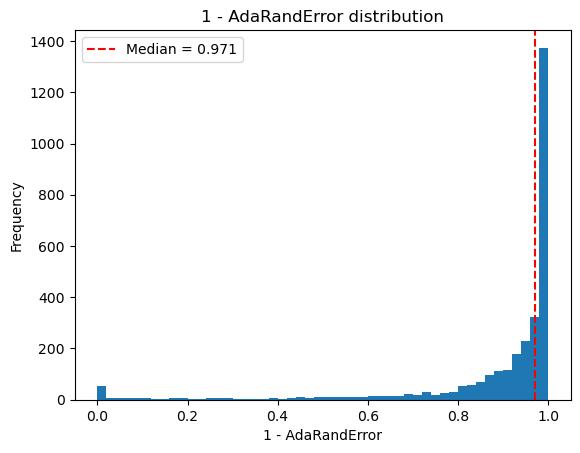

In [44]:
plt.hist(1 - consis_scores2[:, 0], bins=50)
plt.axvline(x=(1-np.nanmedian(consis_scores2[:, 0])), color='r', linestyle='--', label='Median = {:.3f}'.format(1-np.nanmedian(consis_scores2[:, 0])))
plt.title("1 - AdaRandError distribution")
plt.xlabel("1 - AdaRandError")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [99]:
non_nan_ids = np.where(~np.isnan(consis_scores[:, 0]))[0]
print(len(non_nan_ids))

3043


In [100]:
consis_scores.shape

(5120, 3)

In [101]:
5120 - 2076

3044

In [102]:
consis_scores[non_nan_ids].shape

(3043, 3)

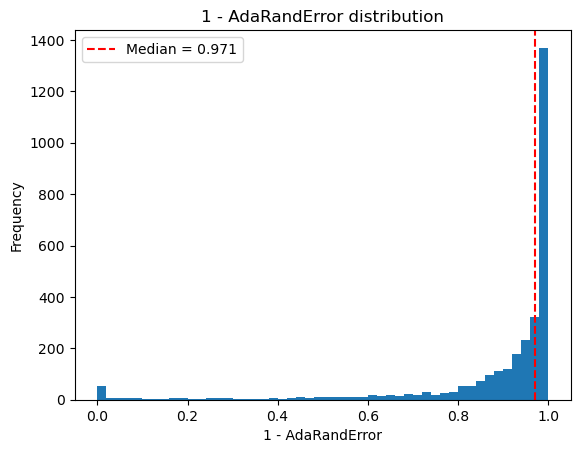

In [103]:
plt.hist(1 - consis_scores[non_nan_ids, 0], bins=50)
plt.axvline(x=(1-np.nanmedian(consis_scores[non_nan_ids, 0])), color='r', linestyle='--', label='Median = {:.3f}'.format(1-np.nanmedian(consis_scores[non_nan_ids, 0])))
plt.title("1 - AdaRandError distribution")
plt.xlabel("1 - AdaRandError")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [86]:
ids_1 = np.where((1 -consis_scores[:, 0] == 1))[0]
print(len(ids_1))

534


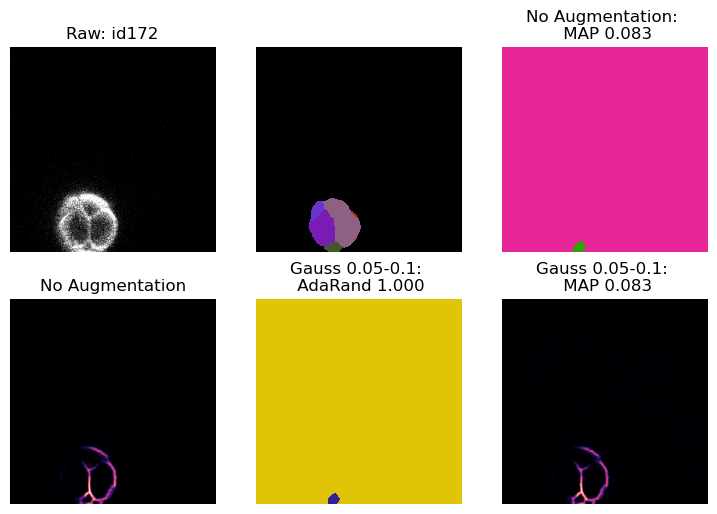

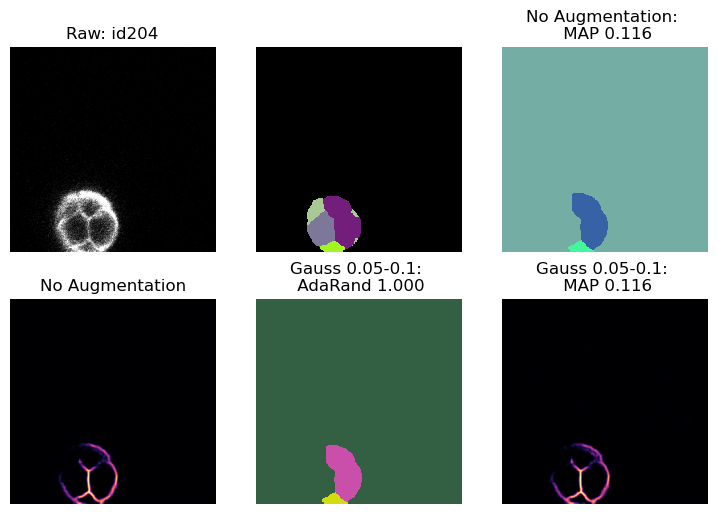

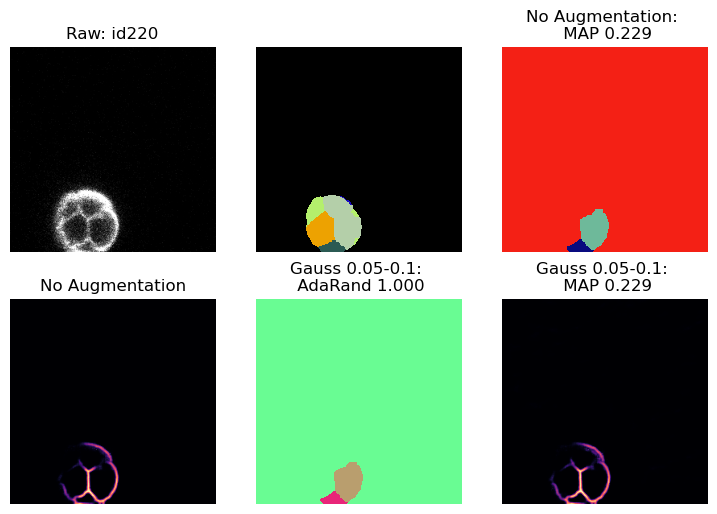

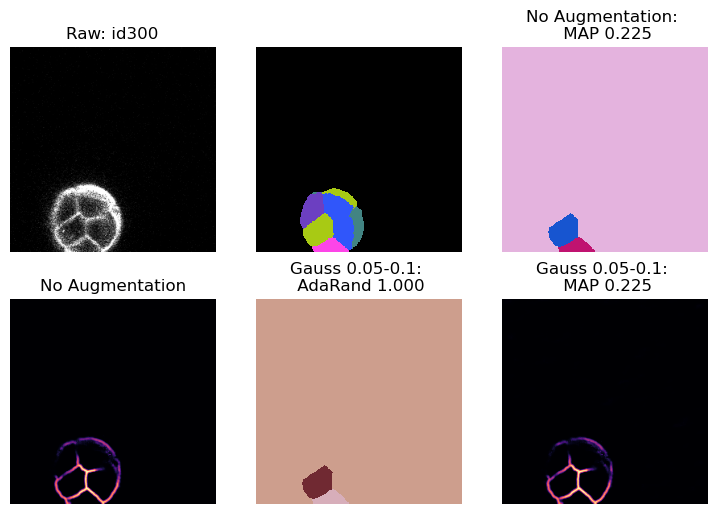

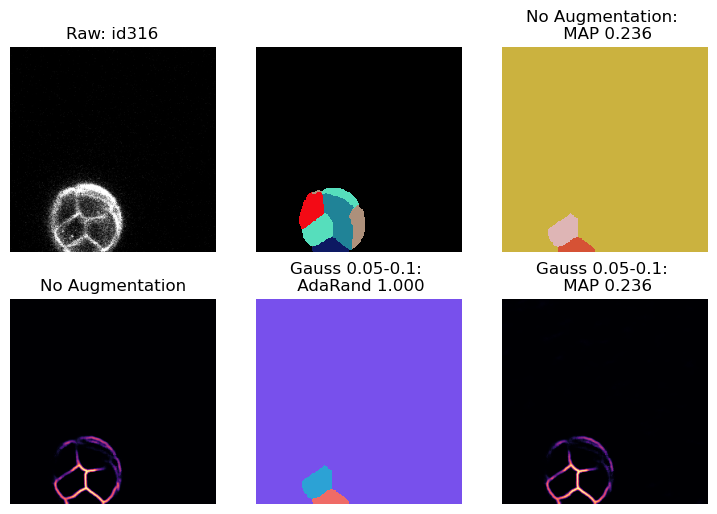

In [88]:
offset = 0
num_samples = 5
for i in ids_1[offset :offset + num_samples]:
    raw = load_h5(ov_raw_path, "raw", select_index=[i])
    gt = load_h5(ov_raw_path, "label", select_index=[i])
    _, axs = plt.subplots(2, 3, figsize=(9, 6))
    axs = axs.ravel()
    axs[0].imshow(raw.squeeze(), cmap="gray")
    axs[0].set_title(f"Raw: id{i}")
    axs[0].axis("off")
    axs[1].imshow(gt.squeeze(), cmap=get_random_colors(gt), interpolation='nearest')
    axs[1].axis("off")
    axs[2].imshow(segs_NA_new[i].squeeze(), cmap=get_random_colors(segs_new[i]), interpolation='nearest')
    axs[2].set_title("No Augmentation: \n MAP {:.3f}".format(MAP_score_NA_new[i]))
    axs[2].axis("off")
    axs[3].imshow(preds_NA_new[i].squeeze(), cmap="magma")
    axs[3].set_title("No Augmentation")
    axs[3].axis("off")
    axs[4].imshow(segs_new[i].squeeze(), cmap=get_random_colors(segs_new[i]), interpolation='nearest')
    axs[4].set_title("Gauss 0.05-0.1: \n AdaRand {:.3f}".format(1 - consis_scores[i, 0]))
    axs[4].axis("off")
    axs[5].imshow(preds_new[i].squeeze(), cmap="magma")
    axs[5].set_title("Gauss 0.05-0.1: \n MAP {:.3f}".format(MAP_score_new[i]))
    axs[5].axis("off")
    plt.show()